f(x,y) = x**2 + x*y + 2*y**2
∂f/∂x = 2*x + y
∂f/∂y = x + 4*y

--- Gradient Values ---
Gradient at (1, 1): [3 5]
Gradient at (1, -1): [ 1 -3]
Gradient at (-1, 1): [-1  3]

Point: (1, 1)
Current: 4
Along gradient: 4.3474
Against gradient: 3.6673999999999998

Point: (1, -1)
Current: 2
Along gradient: 2.1015999999999995
Against gradient: 1.9016

Point: (-1, 1)
Current: 2
Along gradient: 2.1015999999999995
Against gradient: 1.9016


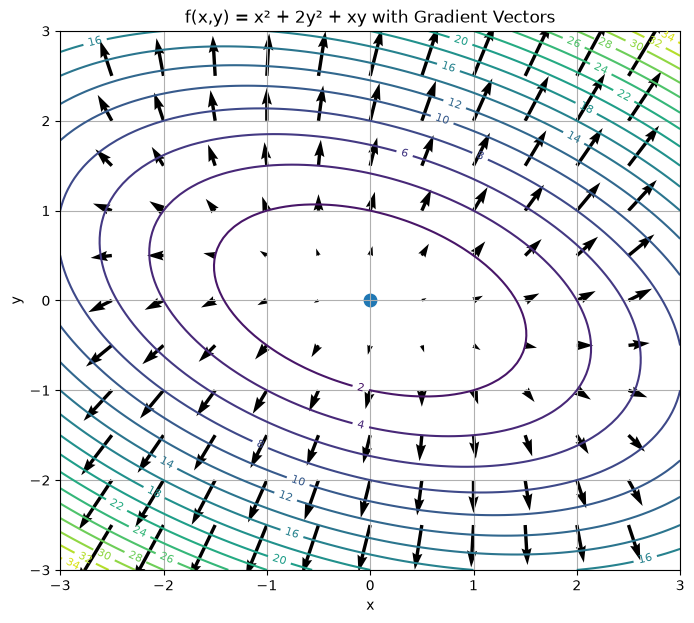

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


# ==========================================
# 1. SymPy partial derivatives
# ==========================================

x, y = sp.symbols('x y')

f = x**2 + 2*y**2 + x*y

df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

print("f(x,y) =", f)
print("∂f/∂x =", df_dx)
print("∂f/∂y =", df_dy)


# ==========================================
# 2. Function
# ==========================================

def f_func(x, y):
    return x**2 + 2*y**2 + x*y


# ==========================================
# 3. Gradient function
# ==========================================

def gradient(px, py):
    return np.array([
        2*px + py,
        px + 4*py
    ])


# ==========================================
# 4. Evaluate gradient at three points
# ==========================================

points = [
    (1, 1),
    (1, -1),
    (-1, 1)
]

print("\n--- Gradient Values ---")

for px, py in points:
    print(
        f"Gradient at ({px}, {py}):",
        gradient(px, py)
    )


# ==========================================
# 5. Check uphill/downhill direction
# ==========================================

def check_gradient_direction(px, py, step=0.01):

    grad = gradient(px, py)

    current = f_func(px, py)

    uphill = f_func(
        px + step * grad[0],
        py + step * grad[1]
    )

    downhill = f_func(
        px - step * grad[0],
        py - step * grad[1]
    )

    print(f"\nPoint: ({px}, {py})")
    print("Current:", current)
    print("Along gradient:", uphill)
    print("Against gradient:", downhill)


for px, py in points:
    check_gradient_direction(px, py)


# ==========================================
# 6. Contour plot
# ==========================================

x_vals = np.linspace(-3, 3, 100)
y_vals = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x_vals, y_vals)

Z = X**2 + 2*Y**2 + X*Y


# ==========================================
# 7. Gradient grid
# ==========================================

grid_x = np.linspace(-2.5, 2.5, 11)
grid_y = np.linspace(-2.5, 2.5, 11)

GX, GY = np.meshgrid(grid_x, grid_y)

U = 2*GX + GY
V = GX + 4*GY


# ==========================================
# 8. Plot
# ==========================================

plt.figure(figsize=(8, 7))

contours = plt.contour(
    X,
    Y,
    Z,
    levels=20
)

plt.clabel(
    contours,
    inline=True,
    fontsize=8
)

plt.quiver(
    GX,
    GY,
    U,
    V
)

plt.scatter(
    0,
    0,
    s=80
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("f(x,y) = x² + 2y² + xy with Gradient Vectors")

plt.grid(True)

plt.show()